In [1]:
# NAME: Bruce Bai
# GITHUB USERNAME (Just in case): bruceb002
# USC ID: 1563103829

import pandas as pd
import seaborn
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

import os
import warnings

# Use 2 cores to balance speed, system stability, and CPU quota
os.environ["LOKY_MAX_CPU_COUNT"] = "2"
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")

In [2]:
# 1a) Utilizing the data that was downloaded

df = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx', sheet_name='Sheet1')
print(df)

# Resources
# https://www.geeksforgeeks.org/python/working-with-excel-files-using-pandas/#google_vignette

         AT      V       AP     RH      PE
0     14.96  41.76  1024.07  73.17  463.26
1     25.18  62.96  1020.04  59.08  444.37
2      5.11  39.40  1012.16  92.14  488.56
3     20.86  57.32  1010.24  76.64  446.48
4     10.82  37.50  1009.23  96.62  473.90
...     ...    ...      ...    ...     ...
9563  16.65  49.69  1014.01  91.00  460.03
9564  13.19  39.18  1023.67  66.78  469.62
9565  31.32  74.33  1012.92  36.48  429.57
9566  24.48  69.45  1013.86  62.39  435.74
9567  21.60  62.52  1017.23  67.87  453.28

[9568 rows x 5 columns]


In [3]:
# 1b) i. 

print("There appears to be 9568 rows and 5 columns.\n")

print("The first four columns represent the four hourly average ambient features: \
Average ambient temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), and Relative Humidity (RH).\n\
The fifth column is the target variable, net hourly electrical energy output (PE).\n")

print("Each row represents the raw, unnormalized values for the four features gathered over an arbitrary hour, \
as well as the target variable (PE) that was measured over that same hour.\n")

# Resource:
# https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant

There appears to be 9568 rows and 5 columns.

The first four columns represent the four hourly average ambient features: Average ambient temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), and Relative Humidity (RH).
The fifth column is the target variable, net hourly electrical energy output (PE).

Each row represents the raw, unnormalized values for the four features gathered over an arbitrary hour, as well as the target variable (PE) that was measured over that same hour.



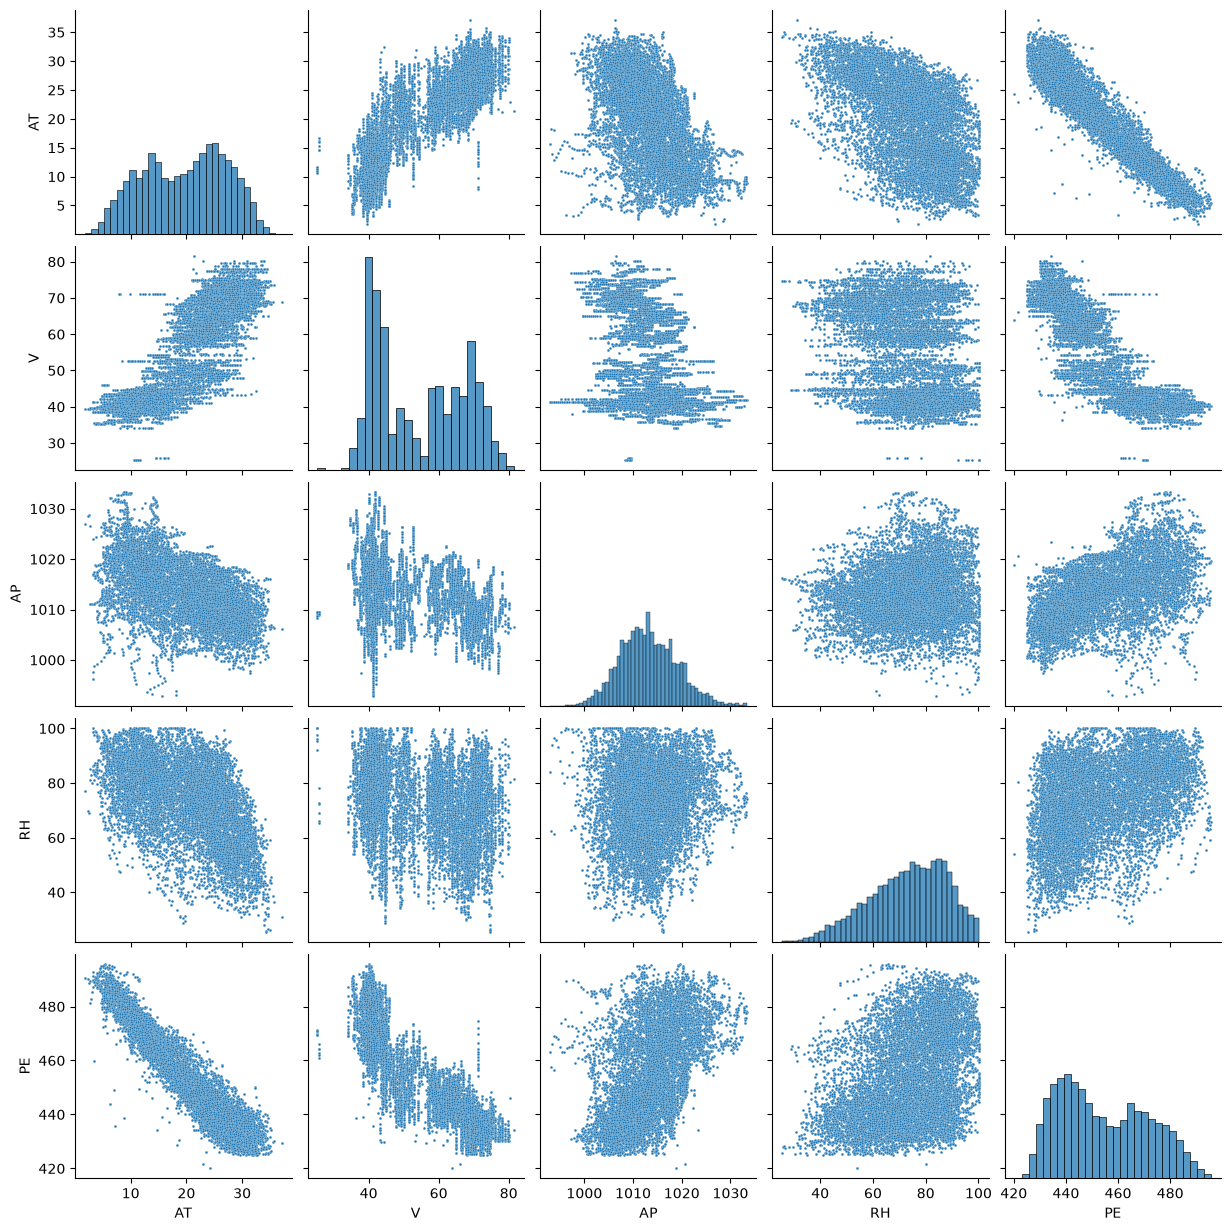

In [4]:
# 1b) ii.

seaborn.pairplot(df, plot_kws={"s": 4})
plt.show()
      
# Resources:
# https://www.geeksforgeeks.org/python/python-seaborn-pairplot-method/
# https://seaborn.pydata.org/generated/seaborn.pairplot.html
# https://www.geeksforgeeks.org/data-visualization/how-to-change-marker-size-in-seaborn-scatterplot/
# https://builtin.com/articles/seaborn-pairplot

In [5]:
# 1b) ii. [CON'T.] --- Written Portion

print("    Right off the bat, the scatterplots reveal which pairs of variables have strong relationships, \
versus those with weak to scattered correlations.", end=" ")

print("    For starters, the two features, Ambient Temperature (AT) and Exhaust Vacuum (V), \
have a notable positive correlation with each other. This indicates potential multi-collinearity \
between these two predictors, which we may need to pay close attention to later on in \
multiple linear regression models.", end=" ")

print("The target variable PE and the exhaust Vacuum V also have a notable negative correlation. \
As V increases, PE decreases.", end=" ")

print("And PE and AT have the clearest correlation of all, with a strong linear negative correlation. \
Evidently, as AT increases, PE decreases.\n")

print("    From there, I recognized that all three variables are strongly correlated with each other. \
To summarize the observed behavior, as AT and V increase, the power output PE will trend downwards. \
Because of these tight trends, AT and V will likely be the strongest predictors for the regression models.\n")

print("    Some other pairs that display weaker, and more dispersed, relations include: slightly negative correlations in \
(AT, AP) and (RH, AT), and a slightly positive correlation for (AP, PE).\n")

print("    Regarding the diagonal distributions, we can see that AT, V, and PE are bimodal graphs (V being the most obvious) \
AP displays as an almost perfect standard bell curve, and RH is notably left-skewed.\n")

    Right off the bat, the scatterplots reveal which pairs of variables have strong relationships, versus those with weak to scattered correlations.     For starters, the two features, Ambient Temperature (AT) and Exhaust Vacuum (V), have a notable positive correlation with each other. This indicates potential multi-collinearity between these two predictors, which we may need to pay close attention to later on in multiple linear regression models. The target variable PE and the exhaust Vacuum V also have a notable negative correlation. As V increases, PE decreases. And PE and AT have the clearest correlation of all, with a strong linear negative correlation. Evidently, as AT increases, PE decreases.

    From there, I recognized that all three variables are strongly correlated with each other. To summarize the observed behavior, as AT and V increase, the power output PE will trend downwards. Because of these tight trends, AT and V will likely be the strongest predictors for the regress

In [6]:
# 1b) iii.

calculated_stats = df.describe()

calculated_stats.loc["range"] = calculated_stats.loc["max"] - calculated_stats.loc["min"]
calculated_stats.loc["iqr"] = calculated_stats.loc["75%"] - calculated_stats.loc["25%"]

final_stats = calculated_stats.drop(index=["count", "min", "max", "std"])

print(final_stats)

# Resources
# Reference to Hmwk0 for Pd.describe()
# Additionally: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
# https://www.geeksforgeeks.org/maths/interquartile-range/
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html

              AT          V           AP         RH          PE
mean   19.651231  54.305804  1013.259078  73.308978  454.365009
25%    13.510000  41.740000  1009.100000  63.327500  439.750000
50%    20.345000  52.080000  1012.940000  74.975000  451.550000
75%    25.720000  66.540000  1017.260000  84.830000  468.430000
range  35.300000  56.200000    40.410000  74.600000   75.500000
iqr    12.210000  24.800000     8.160000  21.502500   28.680000


Based on the statistics and graphs below, I see that both AT and V have a strong correlation with PE. This is further backed by their high R-squared values. On the other hand, AP and RH have pretty weak correlation with PE, and their R-squared values being closer to 0 also reflects that.

On the other hand, I noticed that all the P-values are effectively zero, meaning that the relationship between all the four independent variables and PE is statistically significant and real, and not flukes. Still, AP and RH, while they still display a real relationship between PE, are weaker predictors, in contrast to AT and V.

In terms of outliers, while I will not explicitly be removing them for this assignment, I do think I would clean outliers from AT, V, and AP graphs, but not RH. In the V vs PE plot, there are unnatural vertical lines of data points at the extreme points outside the cluster, which likely indicate measurement errors. In the AT vs PE plot, there is a notable amount of points fal

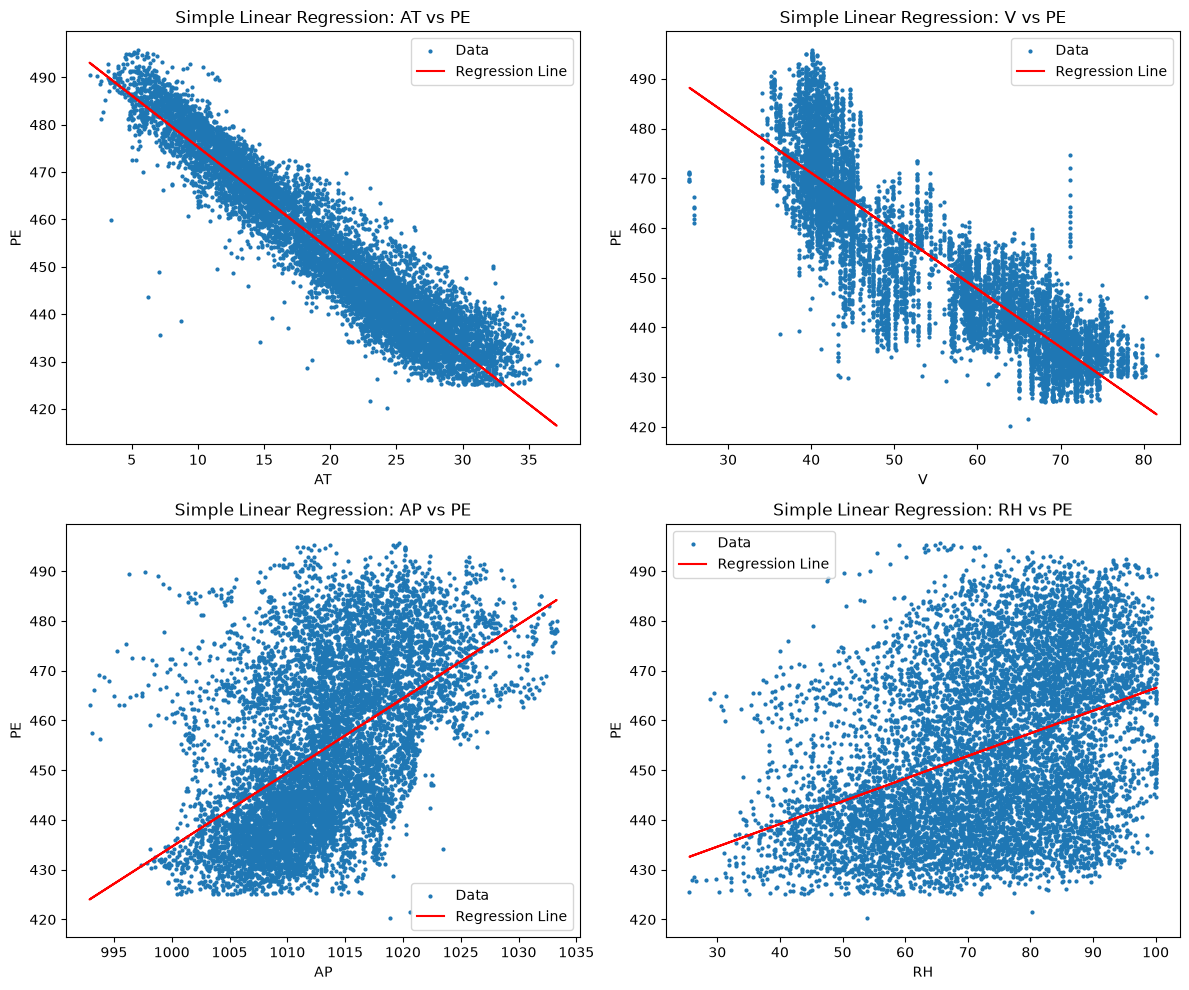

In [7]:
# 1c)

y = df["PE"]
independent_features = ["AT", "V", "AP", "RH"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

print("Based on the statistics and graphs below, I see that both AT and V have a strong correlation with PE. \
This is further backed by their high R-squared values. On the other hand, AP and RH have pretty weak correlation \
with PE, and their R-squared values being closer to 0 also reflects that.\n")
print("On the other hand, I noticed that all the P-values are effectively zero, meaning that the relationship \
between all the four independent variables and PE is statistically significant and real, and not flukes. Still, \
AP and RH, while they still display a real relationship between PE, are weaker predictors, in contrast to AT and V.\n")

print("In terms of outliers, while I will not explicitly be removing them for this assignment, \
I do think I would clean outliers from AT, V, and AP graphs, but not RH. In the V vs PE plot, \
there are unnatural vertical lines of data points at the extreme points outside the cluster, \
which likely indicate measurement errors. In the AT vs PE plot, there is a notable amount of points \
falling far below the main, highly correlated cluster. Similarly, in the AP vs PE plot, \
there is a sparse collection of points in the upper-left quadrant that stray significantly from \
the main data cluster. I would remove those outliers from AT, V, and AP to prevent them from \
disproportionately skewing the regression equations.\n")
print("On the other hand, I would not think of cleaning outliers for RH vs PE. While there are a few slight outliers \
in the upper-left quadrant, the distribution is inherently noisy and widely dispersed. Removing these edge points \
would not make the line of best fit meaningfully more accurate, as the weak relationship is due to \
high natural variance rather than a few extremely skewed measurements.\n")

for i, var_name in enumerate(independent_features):
    X = df[var_name]
    const_added_X = sm.add_constant(X)
    model = sm.OLS(y, const_added_X)
    res = model.fit()

    p_value = res.pvalues[var_name]
    coeff = res.params[var_name]
    r_squared = res.rsquared
    print(f"{var_name} vs PE | P-value: {p_value:.4e} | Coef: {coeff:.4f} | R-squared: {r_squared:.4f}")

    ax = axes[i]
    
    ax.scatter(X, y, s=4, label='Data')
    
    predictions = res.predict(const_added_X)
    ax.plot(X, predictions, color='red', label='Regression Line')
    
    ax.set_title(f"Simple Linear Regression: {var_name} vs PE")
    ax.set_xlabel(var_name)
    ax.set_ylabel("PE")
    ax.legend()

plt.tight_layout()
plt.show()
    
    
# Resources:
# https://www.statsmodels.org/stable/regression.html

In [8]:
# 1d) 

X = df.iloc[:, :-1]
multi_X = sm.add_constant(X)
model = sm.OLS(y, multi_X)
res = model.fit()
print(res.summary())

print("\n")

print("With all the independent variables now combined and considered simultaneously, the R-squared value \
is even higher than the highest correlation found in the simple linear regressions (AT vs PE). This means this multiple regression model \
is highly accurate overall. While AT has the largest unscaled coefficient magnitude (AT: -1.9775, V: -0.2339, AP: 0.0621, RH: -0.1581), \
we would need to standardize the features to definitively rank their impact. However, AT certainly remains a highly significant predictor.\n") 

print("Additionally, the summary warns of strong multi-collinearity since the condition number is exceptionally high. \
The pair of independent variables that are most highly correlated are (AT, V), and this strong correlation \
can cause coefficient estimates to become unstable.\n")

print("Finally, since all p-values are effectively zero (well below the 0.05 threshold), there is overwhelming evidence that \
all coefficients are non-zero and each independent variable contributes to the response. Therefore, \
we reject the null hypothesis for all four independent variables.\n")

# Resources
# https://www.datarobot.com/blog/multiple-regression-using-statsmodels/

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:15:32   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

The weights of each independent variable were not influential in the way as expected when all were in effect simultaneously on the response. The only variable that acted consistently,just as strongly (with around a ~ -2 co-efficient), was AT, proving that it is equally influential to the response nevertheless. The rest strayed further from the single regression model's coefficients. The co-efficient that changed most was RH, as it completely flipped from having a positive coefficient (0.4557) to negative one (-0.1581). Indicating that when all variables are applied simultaneously, it actually influences PE by reducing it, rather than increasing it. This sign flip demonstrates a classic case of omitted variable bias in the simple regression model, where controlling for temperature and pressure fundamental alters the observed relationship between relative humidity and power output. Next, AP's magnitude of effect turned out to not be as large when other variables were considered. Its co-e

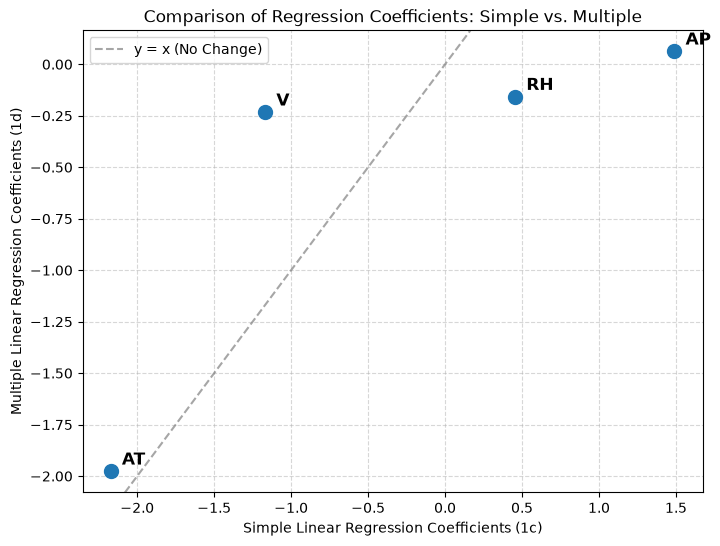

In [9]:
# 1e) 

print("The weights of each independent variable were not influential in the way as expected when all were \
in effect simultaneously on the response. The only variable that acted consistently,just as strongly (with around a ~ -2 \
co-efficient), was AT, proving that it is equally influential to the response nevertheless. \
The rest strayed further from the single regression model's coefficients. The co-efficient that changed most \
was RH, as it completely flipped from having a positive coefficient (0.4557) to negative one (-0.1581). \
Indicating that when all variables are applied simultaneously, it actually influences PE by reducing it, rather than \
increasing it. This sign flip demonstrates a classic case of omitted variable bias in the simple regression model, \
where controlling for temperature and pressure fundamental alters the observed relationship between relative humidity \
and power output. Next, AP's magnitude of effect turned out to not be as large when other variables were considered. Its \
co-efficient dropped from 1.4899 to just 0.0621.\n")

print("Ultimately, it is evident that all variables working together make a more accurate model overall than any of \
them individually could. So overall, the main consensus is that while all variables definitely played a part in \
contributing to the response, their magnitude of effects had different behaviors once they were all taken into account \
at the same time.\n")

simple_coeffs = [-2.1713, -1.1681, 1.4899, 0.4557]  
multi_coeffs = [-1.9775, -0.2339, 0.0621, -0.1581]

plt.figure(figsize=(8, 6))
plt.scatter(simple_coeffs, multi_coeffs, s=100, zorder=5)

for i, txt in enumerate(X):
    plt.annotate(txt, (simple_coeffs[i], multi_coeffs[i]), 
                 xytext=(8, 5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title("Comparison of Regression Coefficients: Simple vs. Multiple")
plt.xlabel("Simple Linear Regression Coefficients (1c)")
plt.ylabel("Multiple Linear Regression Coefficients (1d)")

plt.axline((0, 0), slope=1, color='gray', linestyle='--', alpha=0.7, label='y = x (No Change)')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [10]:
# 1f)
for var_name in independent_features:
    X = df[[var_name]]
    tri_poly = PolynomialFeatures(degree=3, include_bias=True)
    X_poly = tri_poly.fit_transform(X)
    model = sm.OLS(y, X_poly)
    res = model.fit()

    print(f"{var_name}: Non-Linear Terms")
    print("**********************")
    print(f"{var_name} (Linear)    p-value: {res.pvalues.iloc[1]:.4e}")
    print(f"{var_name}^2 (Squared) p-value: {res.pvalues.iloc[2]:.4e}")
    print(f"{var_name}^3 (Cubed)   p-value: {res.pvalues.iloc[3]:.4e}\n")

print("All the independent variables do have non-linear association to the response variable, as all of their \
p-values corresponding to their non-linear terms are all well below the 0.05 threshold. The only feature with a \
non-linear term exceeding a p-value of 0.05 is V, with its squared term having a value of 0.7685. Even then, \
its cubed term has a p-value of 0.013735, well below 0.05. Therefore, V still is statistically significant at the \
cubic polynomial level.\n")

# https://scikit-learn.org/stable/modules/preprocessing.htm\#generating-polynomial-features

AT: Non-Linear Terms
**********************
AT (Linear)    p-value: 7.8981e-07
AT^2 (Squared) p-value: 8.8330e-73
AT^3 (Cubed)   p-value: 3.6522e-110

V: Non-Linear Terms
**********************
V (Linear)    p-value: 2.5266e-05
V^2 (Squared) p-value: 7.6850e-01
V^3 (Cubed)   p-value: 1.3735e-02

AP: Non-Linear Terms
**********************
AP (Linear)    p-value: 4.5027e-17
AP^2 (Squared) p-value: 3.6667e-17
AP^3 (Cubed)   p-value: 8.2641e-18

RH: Non-Linear Terms
**********************
RH (Linear)    p-value: 3.7725e-04
RH^2 (Squared) p-value: 9.3954e-06
RH^3 (Cubed)   p-value: 1.4403e-05

All the independent variables do have non-linear association to the response variable, as all of their p-values corresponding to their non-linear terms are all well below the 0.05 threshold. The only feature with a non-linear term exceeding a p-value of 0.05 is V, with its squared term having a value of 0.7685. Even then, its cubed term has a p-value of 0.013735, well below 0.05. Therefore, V still i

In [11]:
# 1g)

equation = "PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH"
model_interactions = smf.ols(formula=equation, data=df)
res = model_interactions.fit()
print(res.summary())

print("")

print("There is evidence that several interactions between predictors are associated with the response. By running a full linear regression model with all \
pairwise interaction terms, we can evaluate their statistical significance based on the threshold p=0.05. The model indicates that four of the six interaction terms \
are statistically significant: AT:V (p = 0.000), AT:RH (p = 0.000), V:AP (p = 0.000), and AP:RH (p = 0.034). Conversely, the interaction terms for AT:AP (p = 0.452) \
and V:RH (p = 0.086) are not statistically significant. It is also worth noting that introducing these interaction terms worsened the multicollinearity in the model \
(Condition Number: 1.70e+08), which shifted some of the predictive weight away from the main effects and into the significant interaction terms.\n")

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:15:32   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [12]:
#1h) 

train_data, test_data = train_test_split(df, test_size=0.30, random_state=37)
baseline_formula = "PE ~ AT + V + AP + RH"
baseline_model = smf.ols(formula=baseline_formula, data=train_data)
res = baseline_model.fit()

base_train_pred = res.predict(train_data)
base_test_pred = res.predict(test_data)

base_train_mse = mean_squared_error(train_data['PE'], base_train_pred)
base_test_mse = mean_squared_error(test_data['PE'], base_test_pred)

print(f"Baseline Model")
print("****************")
print(f"Train MSE: {base_train_mse:.4f}")
print(f"Test MSE:  {base_test_mse:.4f}\n")

full_formula = ("PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)")

full_model = smf.ols(formula=full_formula, data=train_data)
res = full_model.fit()
print("Full Expanded Model Summary:")
print("****************************\n")
print(res.summary())

Baseline Model
****************
Train MSE: 20.9981
Test MSE:  20.2442

Full Expanded Model Summary:
****************************

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     7174.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:15:32   Log-Likelihood:                -19228.
No. Observations:                6697   AIC:                         3.849e+04
Df Residuals:                    6682   BIC:                         3.859e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-

In [13]:
# 1h) [CON'T.] --- Removing AT:AP since this interaction term isn't protecting any higher-degree term

round2_formula = ("PE ~ AT + V + AP + RH + AT:V + AT:RH + V:AP + V:RH + AP:RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)")

model_r2 = smf.ols(formula=round2_formula, data=train_data)
res = model_r2.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7727.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:15:32   Log-Likelihood:                -19228.
No. Observations:                6697   AIC:                         3.848e+04
Df Residuals:                    6683   BIC:                         3.858e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8507.0014   1257.752     -6.764      0.0

In [14]:
# 1h) [CON'T.] Removing V:RH since it has the next highest p-value

round3_formula = ("PE ~ AT + V + AP + RH + AT:V + AT:RH + V:AP + AP:RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)")

model_r3 = smf.ols(formula=round3_formula, data=train_data)
res = model_r3.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     8371.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:15:33   Log-Likelihood:                -19228.
No. Observations:                6697   AIC:                         3.848e+04
Df Residuals:                    6684   BIC:                         3.857e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8566.2429   1255.839     -6.821      0.0

In [15]:
# 1h) [CON'T.] Finally, we remove the only insignificant interaction term -- I(V**2)

final_formula = ("PE ~ AT + V + AP + RH + AT:V + AT:RH + V:AP + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)")
final_model = smf.ols(formula=final_formula, data=train_data)
res = final_model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9133.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:15:33   Log-Likelihood:                -19229.
No. Observations:                6697   AIC:                         3.848e+04
Df Residuals:                    6685   BIC:                         3.856e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8617.2549   1253.901     -6.872      0.0

In [16]:
# 1h) [CON'T.]

final_train_pred = res.predict(train_data)
final_test_pred = res.predict(test_data)

final_train_mse = mean_squared_error(train_data['PE'], final_train_pred)
final_test_mse = mean_squared_error(test_data['PE'], final_test_pred)

print(f"Final Pruned Model MSEs")
print("***********************")
print(f"Train MSE: {final_train_mse:.4f}")
print(f"Test MSE:  {final_test_mse:.4f}")

print("")

print("The model indeed can be improved using interaction terms and nonlinear associations. After adding all pairwise interactions and quadratic terms, I pruned \
the insignificant variables (AT:AP, V:RH, and V^2) using p-values while respecting hierarchy. Testing both models on the 30% holdout data resulted train MSE score of 20.9981, \
and test MSE score of 20.2442.\n")
print("In contrast, for the pruned model, the train MSE score was down to 18.2579, and the test MSE was down to 17.8023. Because the Test MSE dropped from 20.24 to 17.80, \
the pruned model is better at predicting unseen data.\n")

Final Pruned Model MSEs
***********************
Train MSE: 18.2579
Test MSE:  17.8023

The model indeed can be improved using interaction terms and nonlinear associations. After adding all pairwise interactions and quadratic terms, I pruned the insignificant variables (AT:AP, V:RH, and V^2) using p-values while respecting hierarchy. Testing both models on the 30% holdout data resulted train MSE score of 20.9981, and test MSE score of 20.2442.

In contrast, for the pruned model, the train MSE score was down to 18.2579, and the test MSE was down to 17.8023. Because the Test MSE dropped from 20.24 to 17.80, the pruned model is better at predicting unseen data.



RAW FEATURES:
****************
Best k: 8 (Lowest Test MSE: 16.2005)

NORMALIZED FEATURES
****************
Best k: 6 (Lowest Test MSE: 15.2005)


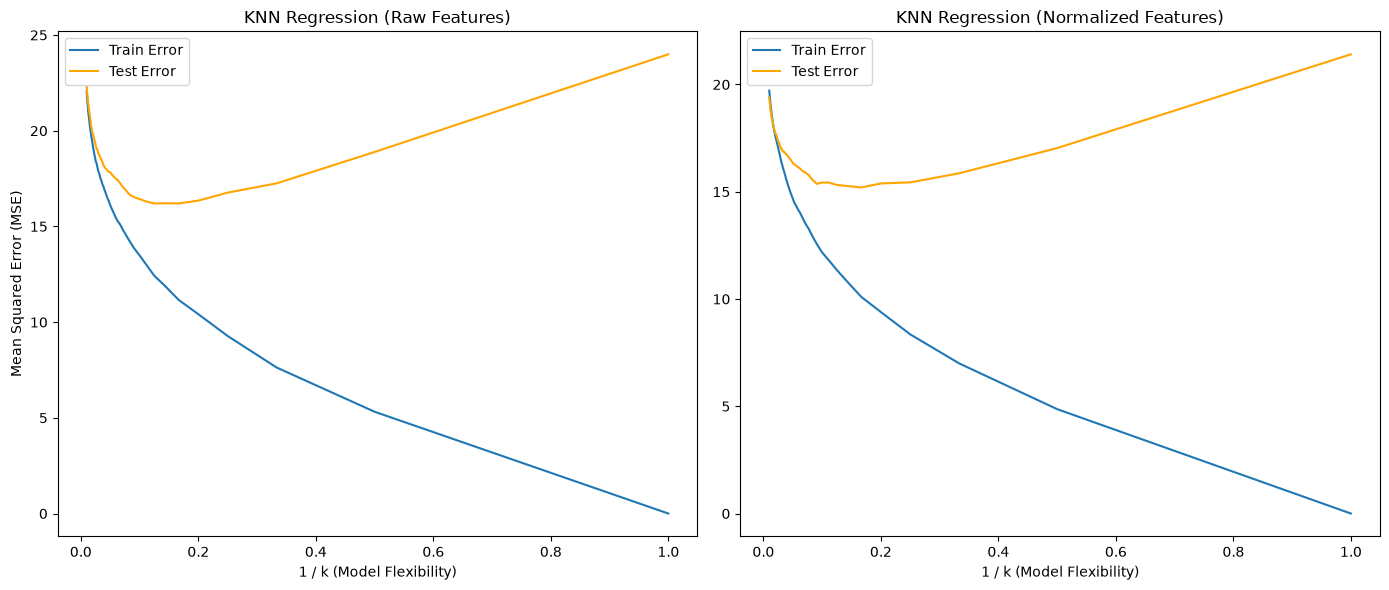

In [17]:
X_train = train_data[independent_features]
y_train = train_data["PE"]
X_test = test_data[independent_features]
y_test = test_data["PE"]

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

k_values = list(range(1, 101))
inverted_k = [1/k for k in k_values]

raw_train_mse = []
raw_test_mse = []
norm_train_mse = []
norm_test_mse = []

for k in k_values:
    # Raw features
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train, y_train)
    raw_train_mse.append(mean_squared_error(y_train, knn_raw.predict(X_train)))
    raw_test_mse.append(mean_squared_error(y_test, knn_raw.predict(X_test)))

    # Normalized features
    knn_norm = KNeighborsRegressor(n_neighbors=k)
    knn_norm.fit(X_train_norm, y_train)
    norm_train_mse.append(mean_squared_error(y_train, knn_norm.predict(X_train_norm)))
    norm_test_mse.append(mean_squared_error(y_test, knn_norm.predict(X_test_norm)))

best_k_raw = k_values[np.argmin(raw_test_mse)]
best_k_norm = k_values[np.argmin(norm_test_mse)]

best_mse_raw = min(raw_test_mse)
best_mse_norm = min(norm_test_mse)

print(f"RAW FEATURES:")
print("****************")
print(f"Best k: {best_k_raw} (Lowest Test MSE: {best_mse_raw:.4f})")

print(f"\nNORMALIZED FEATURES")
print("****************")
print(f"Best k: {best_k_norm} (Lowest Test MSE: {best_mse_norm:.4f})")

# Plotting
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(inverted_k, raw_train_mse, label='Train Error')
plt.plot(inverted_k, raw_test_mse, label='Test Error', color='orange')
plt.xlabel('1 / k (Model Flexibility)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('KNN Regression (Raw Features)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(inverted_k, norm_train_mse, label='Train Error')
plt.plot(inverted_k, norm_test_mse, label='Test Error', color='orange')
plt.xlabel('1 / k (Model Flexibility)')
plt.title('KNN Regression (Normalized Features)')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# 1j)

print("The K-Nearest Neighbors (KNN) regression outperformed my optimized linear regression model. The pruned linear model achieved a Test MSE of 17.8023. \
In contrast, the KNN model using raw features achieved a lowest Test MSE of 16.2005 at k=8. The performance was further improved by normalizing the features, \
which yielded the lowest overall Test MSE of 15.2005 at k=6.\n")

print("As for the analysis, KNN having better results than any approach to linear regression in this assignment shows how the data is not necessarily best fit to be linear \
and instead polynomial. Therefore, KNN's non-parametric approach leads to better results than a rigid linear equation. Normalizing the features further improved the results \
so that variables with much larger values don't dominate the distance calculations. Finally, these graphs in terms of 1/k show optimal k-values being lower values \
(ie. high flexibility), and the same results show how overfitting and test errors easily rise to the right, since k trends towards 1, and relying on a single neighbor will \
evidently overfit.")

The K-Nearest Neighbors (KNN) regression outperformed my optimized linear regression model. The pruned linear model achieved a Test MSE of 17.8023. In contrast, the KNN model using raw features achieved a lowest Test MSE of 16.2005 at k=8. The performance was further improved by normalizing the features, which yielded the lowest overall Test MSE of 15.2005 at k=6.

As for the analysis, KNN having better results than any approach to linear regression in this assignment shows how the data is not necessarily best fit to be linear and instead polynomial. Therefore, KNN's non-parametric approach leads to better results than a rigid linear equation. Normalizing the features further improved the results so that variables with much larger values don't dominate the distance calculations. Finally, these graphs in terms of 1/k show optimal k-values being lower values (ie. high flexibility), and the same results show how overfitting and test errors easily rise to the right, since k trends towards 

In [19]:
# ISLR: 2.4.1

"""
1. For each of parts (a) through (d), indicate whether we would generally
expect the performance of a flexible statistical learning method to be
better or worse than an inflexible method. Justify your answer.

(a) The sample size n is extremely large, and the number of predictors
p is small.
(b) The number of predictors p is extremely large, and the number
of observations n is small.
(c) The relationship between the predictors and response is highly
non-linear.
(d) The variance of the error terms, i.e. σ2 = Var(ϵ), is extremely
high.
"""

print("1a). For this, if the data size is large and we have limited predictor variables, we would expect a flexible learning method to perform better because \
it would be able to utilize the excess datapoints and not need to worry about overfitting. However, a inflexible method would be too rigid, and not be able to \
capture complex shapes / forms when it comes to an extremely large dataset.\n")

print("1b). Here, we would expect the flexible method to be worse, because there would be a lack of datapoints for too many predictor variables, which might cause it to \
graph it too accurately with many variables and for it to try covering all noise and outliers. An inflexible method however, would utilize its rigidness and not overfit to \
said noise/outliers.\n")

print("1c) A flexible model would perform better because we would then need to be able to expect a graph of any shape/form possible. For example in our assignment, KNN, \
a flexible model, was able to perform better namely because some relations between variables were non-linear (nevertheless if they were highly non-linear). As we saw, \
the (rigid) linear regression method performed slightly worse because it wasn't able to capture the complex (non-linear) form of the graph.\n")

print("1d) The flexible models would perform worse, because with high variance comes a lot of noise, to the point where the graph wouldn't have any structured form/shape. \
As such, a flexible model would try to learn a noisy, more unstructured, graph, and then end up severely overfitting. A rigid model would ignore the noise and capture the \
broad trend.\n")


1a). For this, if the data size is large and we have limited predictor variables, we would expect a flexible learning method to perform better because it would be able to utilize the excess datapoints and not need to worry about overfitting. However, a inflexible method would be too rigid, and not be able to capture complex shapes / forms when it comes to an extremely large dataset.

1b). Here, we would expect the flexible method to be worse, because there would be a lack of datapoints for too many predictor variables, which might cause it to graph it too accurately with many variables and for it to try covering all noise and outliers. An inflexible method however, would utilize its rigidness and not overfit to said noise/outliers.

1c) A flexible model would perform better because we would then need to be able to expect a graph of any shape/form possible. For example in our assignment, KNN, a flexible model, was able to perform better namely because some relations between variables we

In [20]:
# ISLR: 2.4.7
"""
7. The table below provides a training data set containing six observations,
three predictors, and one qualitative response variable.
Obs. X1 X2 X3 Y
1 0 3 0 Red
2 2 0 0 Red
3 0 1 3 Red
4 0 1 2 Green
5 −1 0 1 Green
6 1 1 1 Red
Suppose we wish to use this data set to make a prediction for Y when
X1 = X2 = X3 = 0 using K-nearest neighbors.
(a) Compute the Euclidean distance between each observation and
the test point, X1 = X2 = X3 = 0.
(b) What is our prediction with K = 1? Why?
(c) What is our prediction with K = 3? Why?
(d) If the Bayes decision boundary in this problem is highly nonlinear,
then would we expect the best value for K to be large or
small? Why?
"""

print("7a) The formula to find the euclidean distance from the origin is basically sqrt([X1]^2+[X2]^2+[X3]^2):\n\
      Obs. 1: sqrt(0 + 9 + 0) = sqrt(9) = 3\n\
      Obs. 2: sqrt(4 + 0 + 0) = sqrt(4) = 2\n\
      Obs. 3: sqrt(0 + 1 + 9) = sqrt(10) ~= 3.16\n\
      Obs. 4: sqrt(0 + 1 +  4) = sqrt(5) ~= 2.24\n\
      Obs. 5: sqrt(1 + 0 + 1) = sqrt(2) ~= 1.41\n\
      Obs. 6: sqrt(1 + 1 + 1) = sqrt(3) ~= 1.73\n")

print("7b) With K=1, the nearest immediate neighbor would be Obs. 5 at a minimal distance of ~1.41, classifying as 'Green'\n")
print("7c) With K=3, the nearest three neighbors would be: Obs. 5 (Green), Obs. 6 (Red), and Obs. 2 (Red). Therefore it would classify as 'Red'\n")
print("7d) If the Bayes decision boundary in this problem is non-linear, we would expect the best value for K to be small because it would act more flexibly, easily wrapping \
around the non-linear lines. If K were too large, it would try to graph too rigidly/too smooth.\n")
      



7a) The formula to find the euclidean distance from the origin is basically sqrt([X1]^2+[X2]^2+[X3]^2):
      Obs. 1: sqrt(0 + 9 + 0) = sqrt(9) = 3
      Obs. 2: sqrt(4 + 0 + 0) = sqrt(4) = 2
      Obs. 3: sqrt(0 + 1 + 9) = sqrt(10) ~= 3.16
      Obs. 4: sqrt(0 + 1 +  4) = sqrt(5) ~= 2.24
      Obs. 5: sqrt(1 + 0 + 1) = sqrt(2) ~= 1.41
      Obs. 6: sqrt(1 + 1 + 1) = sqrt(3) ~= 1.73

7b) With K=1, the nearest immediate neighbor would be Obs. 5 at a minimal distance of ~1.41, classifying as 'Green'

7c) With K=3, the nearest three neighbors would be: Obs. 5 (Green), Obs. 6 (Red), and Obs. 2 (Red). Therefore it would classify as 'Red'

7d) If the Bayes decision boundary in this problem is non-linear, we would expect the best value for K to be small because it would act more flexibly, easily wrapping around the non-linear lines. If K were too large, it would try to graph too rigidly/too smooth.



### Appendix: Generative AI Attribution & Disclosure

**Citation (MLA Style)** 
Gemini. "Assistance with statsmodels syntax, interaction term hierarchy, and regression analysis for DSCI 552 HW2." Gemini, Large Language Model, Google, 25 Sept. 2026, gemini.google.com.

**Scope of Assistance** 
Per course guidelines, Generative AI was utilized as an interactive learning tool for conceptual clarification, syntax reference, and debugging:

* **Workflow & Syntax:** Consulted for `statsmodels` formula syntax (specifically formatting interactions `A:B` vs. quadratics `I(A**2)`) and templating the iterative model pruning process. AI-suggested code snippets were manually reviewed, restructured by me (e.g., separating chained `.fit()` calls), and cross-referenced with official scikit-learn and statsmodels documentation.
* **Conceptual Understanding:** Clarifying statistical theory, specifically the Principle of Marginality (hierarchy of terms) during variable pruning, the bias-variance tradeoff for the ISLR textbook questions, and the mechanics of random seeds in data splitting.
* **Analysis & Write-ups:** AI was used as a conceptual sounding board to verify my statistical interpretations (e.g., comparing parametric OLS vs. non-parametric KNN, and the impact of normalization). All final written analyses were drafted independently in my own words. I personally analyzed the statistical outputs (such as p-values and MSE scores) to ensure full comprehension of how the variables' relationships tied into the broader ML concepts.

**Representative Prompts**
* *"wait is AT**2 or AP**2 not higher in the hierarchy than AT:AP?"*
* *"for random state why did we choose 42? Can we choose a different number"*
* *"What do I do? Do I do a write-up here?"*